# **Starbucks Customer Order Behavior**
![https://imageio.forbes.com/specials-images/imageserve/6910cb142b1f33203f45dc22/Augusta--Georgia--Starbucks-Coffee--Baristas-at-work-making-drinks/0x0.jpg?format=jpg&width=480](http://https://imageio.forbes.com/specials-images/imageserve/6910cb142b1f33203f45dc22/Augusta--Georgia--Starbucks-Coffee--Baristas-at-work-making-drinks/0x0.jpg?format=jpg&width=480)

This analysis aims to understand Starbucks customer ordering patterns and how digitization, loyalty programs, and product customization drive the company's revenue.

In [1]:
install.packages("RKaggle")
library(RKaggle)
library(tidyverse)
library(dbplyr)
library(dplyr)
library(ggplot2)
library(janitor)
library(lubridate)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘dbplyr’




The following objects are masked from ‘package:dplyr’:

    ident, sql





Attaching package: ‘janitor’




The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Get the dataset from "likithagedipudi/starbucks-customer-ordering-patterns"

In [2]:
starbuck_customer_data <- get_dataset("likithagedipudi/starbucks-customer-ordering-patterns")

Rows: 100000 Columns: 20


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (10): customer_id, order_id, day_of_week, order_channel, store_id, stor...
dbl   (5): cart_size, num_customizations, total_spend, fulfillment_time_min,...
lgl   (3): is_rewards_member, has_food_item, order_ahead
date  (1): order_date
time  (1): order_time



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
head(starbuck_customer_data)
summary(starbuck_customer_data)


customer_id,order_id,order_date,order_time,day_of_week,order_channel,store_id,store_location_type,region,customer_age_group,customer_gender,is_rewards_member,cart_size,num_customizations,total_spend,fulfillment_time_min,drink_category,has_food_item,order_ahead,customer_satisfaction
<chr>,<chr>,<date>,<time>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>,<dbl>
CUST_12974,ORD_00000001,2024-03-25,08:47:00,Mon,Drive-Thru,STR_340,Suburban,Southwest,18-24,Male,FALSE,5,0,14.48,8.2,Refresher,FALSE,FALSE,4
CUST_08235,ORD_00000002,2025-07-18,08:02:00,Fri,Mobile App,STR_425,Urban,Northeast,35-44,Female,TRUE,1,3,9.52,5.4,Brewed Coffee,FALSE,TRUE,4
CUST_00393,ORD_00000003,2025-01-15,05:40:00,Wed,Kiosk,STR_103,Suburban,Midwest,25-34,Female,FALSE,2,1,9.32,4.9,Brewed Coffee,FALSE,FALSE,5
CUST_06936,ORD_00000004,2024-07-30,15:10:00,Tue,Drive-Thru,STR_318,Suburban,Midwest,25-34,Female,TRUE,2,1,9.55,3.5,Refresher,FALSE,FALSE,4
CUST_09800,ORD_00000005,2024-06-18,07:38:00,Tue,Drive-Thru,STR_338,Suburban,Northeast,35-44,Female,FALSE,3,1,12.24,4.1,Frappuccino,FALSE,FALSE,3
CUST_04338,ORD_00000006,2025-08-30,11:41:00,Sat,Mobile App,STR_497,Rural,Northeast,45-54,Male,TRUE,5,1,21.13,5.0,Brewed Coffee,TRUE,FALSE,4


 customer_id          order_id           order_date          order_time      
 Length:100000      Length:100000      Min.   :2024-01-01   Length:100000    
 Class :character   Class :character   1st Qu.:2024-06-30   Class1:hms       
 Mode  :character   Mode  :character   Median :2025-01-01   Class2:difftime  
                                       Mean   :2024-12-30   Mode  :numeric   
                                       3rd Qu.:2025-07-02                    
                                       Max.   :2025-12-30                    
 day_of_week        order_channel        store_id         store_location_type
 Length:100000      Length:100000      Length:100000      Length:100000      
 Class :character   Class :character   Class :character   Class :character   
 Mode  :character   Mode  :character   Mode  :character   Mode  :character   
                                                                             
                                                                

**Recency, Frequency, and Monetary (RFM) Analysis**
Objective: To quantify customer value based on how recently they shopped, how often they visit, and how much they spend.
* Process: We aggregated the transaction data by customer_id to calculate the RFM metrics.
* Metric: * Recency: Days since the last order.
  > * Frequency: Total number of transactions.
  > * Monetary: Total spending across all visits.
* Insight: This step provides a baseline for identifying our "Whale" customers (High Frequency, High Monetary) versus "At-Risk" customers (High Recency).

In [4]:
#average order starbuck
starbuck_average_ordered <- starbuck_customer_data %>% 
  summarise(mean_item = round(mean(cart_size, na.rm = TRUE)))
print (starbuck_average_ordered)

# A tibble: 1 × 1
  mean_item
      <dbl>
1         4


In [5]:
#customer age distribution
age_distribution <- starbuck_customer_data %>% 
  count(customer_age_group, name = "number") %>% 
  mutate(percentage = round(number / sum(number) * 100, 2))

print(age_distribution)

# A tibble: 5 × 3
  customer_age_group number percentage
  <chr>               <int>      <dbl>
1 18-24               20274       20.3
2 25-34               29782       29.8
3 35-44               24543       24.5
4 45-54               15382       15.4
5 55+                 10019       10.0


**Customer Persona Classification**
Objective: To segment customers into actionable groups based on their behavioral traits (Frequency & Customization).
* Process: Using case_when, we categorized customers into:
  > * Coffee Enthusiasts: High frequency (>= 6) and high customization (>= 2.0).
  > * Morning Commuters: High frequency (>= 6) but low customization (< 2.0).
* Metric: * Recency: Days since the last order.
  > * Frequency: Total number of transactions.
  > * Monetary: Total spending across all visits.
* Visualization: A Clustered Bar chart displaying direct comparison between Digital and Physical order based on age group.
* Insight: This step provides a baseline for identifying our "Whale" customers (High Frequency, High Monetary) versus "At-Risk" customers (High Recency).

In [6]:
# Classification digital vs physical
starbuck_customer_data <- starbuck_customer_data %>%
  mutate(channel_type = case_when(
    order_channel %in% c("Mobile App", "Kiosk") ~ "Digital",
    order_channel %in% c("Cashier", "Drive-Thru") ~ "Physical"
  )) %>% 
  filter(!is.na(channel_type))

# Print terpisah
print(unique(starbuck_customer_data$channel_type))

[1] "Physical" "Digital" 


In [7]:
migration_analysis <- starbuck_customer_data %>%
  group_by(customer_age_group, channel_type) %>%
  summarise(count = n(), .groups = 'drop') %>%
  group_by(customer_age_group) %>%
  mutate(percentage = round(count / sum(count) * 100, 2)) %>%
  arrange(customer_age_group)

print(migration_analysis)

# A tibble: 10 × 4
# Groups:   customer_age_group [5]
   customer_age_group channel_type count percentage
   <chr>              <chr>        <int>      <dbl>
 1 18-24              Digital      12110       70.3
 2 18-24              Physical      5118       29.7
 3 25-34              Digital      17852       70.5
 4 25-34              Physical      7478       29.5
 5 35-44              Digital      11033       59.9
 6 35-44              Physical      7389       40.1
 7 45-54              Digital       6982       60.6
 8 45-54              Physical      4549       39.4
 9 55+                Digital       1964       36.2
10 55+                Physical      3462       63.8


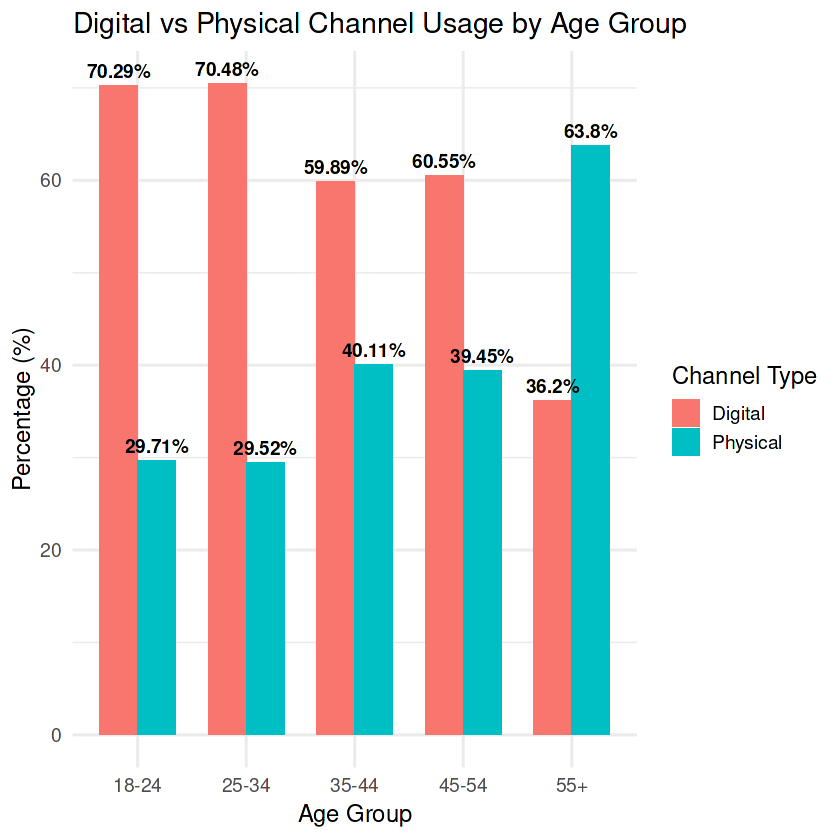

In [8]:
#visualization of digital adoption based on age group
ggplot(migration_analysis, 
         aes(x = customer_age_group, 
             y = percentage, 
             fill = channel_type)) +
    
    geom_col(position = "dodge", width = 0.7) +
    
    geom_text(aes(label = paste0(percentage, "%")), 
              position = position_dodge(width = 0.7),
              vjust = -0.5,
              fontface = "bold") +
    
    theme_minimal(base_size = 14) +
    
    labs(
      title = "Digital vs Physical Channel Usage by Age Group",
      x = "Age Group",
      y = "Percentage (%)",
      fill = "Channel Type"
    )

# **Customer Persona Classification**
Objective: To segment customers into actionable groups based on their behavioral traits (Frequency & Customization).
* Process: Using case_when, we categorized customers into:
  > * Coffee Enthusiasts: High frequency (>= 6) and high customization (>= 2.0).
  > * Morning Commuters: High frequency (>= 6) but low customization (< 2.0).
  > * Regular Customers: Moderate frequency (3 to 5 visits).
* Visualization: A scatter plot displaying Frequency vs. Monetary, colored by Persona.
* Insight: Coffee Enthusiasts are our most valuable segment as they drive revenue through expensive add-ons.

In [9]:
#predictive Analysis using RFM score
rfm_data <- starbuck_customer_data %>%
  group_by(customer_id) %>%
  summarise(
    Recency = as.numeric(as.Date("2024-01-01") - max(as.Date(order_date))), # Days since last order
    Frequency = n(),                                                        # Total visits
    Monetary = sum(total_spend, na.rm = TRUE),                              # Total expenses
    Avg_Customization = mean(num_customizations, na.rm = TRUE)              # Additions for Coffee Enthusiasts
  )

In [10]:
#coffee vs morning Commuters data
rfm_segments <- rfm_data %>%
  mutate(persona = case_when(
    Frequency >= 6 & Avg_Customization >= 2.0 ~ "Coffee Enthusiast",
    Frequency >= 6 & Avg_Customization < 2.0 ~ "Morning Commuter",
    Frequency < 6 & Frequency >= 3 ~ "Regular Customer" 
  ))%>%
  filter(!is.na(persona))

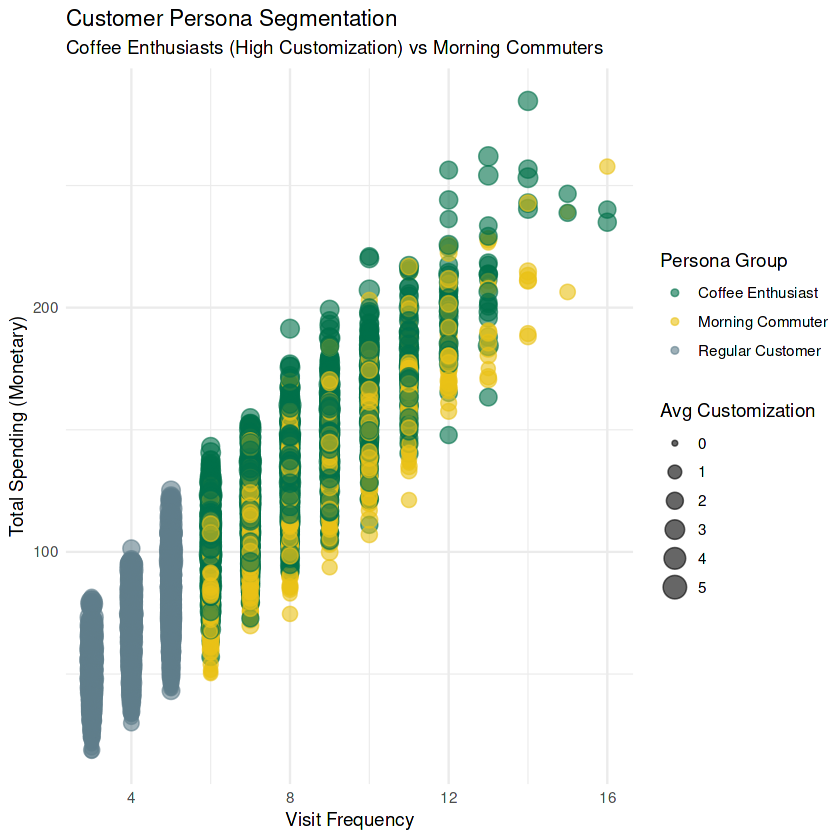

In [11]:
#coffee vs morning Commuters data visualization 
ggplot(rfm_segments, aes(x = Frequency, y = Monetary, color = persona)) +
  geom_point(aes(size = Avg_Customization), alpha = 0.6) +
  theme_minimal() +
  # Menggunakan warna brand Starbucks agar lebih profesional
  scale_color_manual(values = c(
    "Coffee Enthusiast" = "#00704A", 
    "Morning Commuter" = "#EAC117", 
    "Regular Customer" = "#607D8B"
  )) +
  labs(
    title = "Customer Persona Segmentation",
    subtitle = "Coffee Enthusiasts (High Customization) vs Morning Commuters",
    x = "Visit Frequency",
    y = "Total Spending (Monetary)",
    color = "Persona Group",
    size = "Avg Customization"
  )

# **Predictive Revenue Modeling**
Objective: To build a regression model that predicts total_spend based on transaction context.
* Method: Multiple Linear Regression (lm).
* Formula:
  > *TotalSpend∼OrderTime+LocationType+CustomizationCount*
* Validation: We used an Actual vs. Predicted plot to evaluate model performance
* Insight: Customization counts have a positive coefficient, meaning every additional modification directly increases the predicted revenue.

In [12]:
#regression models to predict total_spend based on time of day, store location type, and customization counts.

In [13]:
# 1. Preparing data with clean time grouping
reg_data <- starbuck_customer_data %>% 
  mutate(
    # Take the first 2 digits of the hour (e.g., “08” from “08:00”)
    hour = as.numeric(substr(order_time, 1, 2)),
    # Creating time categories
    time_category = case_when(
      hour >= 5 & hour < 12 ~ "Morning",
      hour >= 12 & hour < 17 ~ "Afternoon",
      TRUE ~ "Evening"
    ),
    # Converting variables into factors    
    time_category = as.factor(time_category),
    store_location_type = as.factor(store_location_type)
  ) %>%
  # Ensure there are no empty lines that cause variable length errors
  filter(!is.na(total_spend), !is.na(num_customizations))


In [14]:
# 2. Build the model using ‘time_category’ instead of the messy ‘order_time’.
revenue_model <- lm(total_spend ~ time_category + store_location_type + num_customizations, 
                    data = reg_data)

In [15]:
# 3. See the results
summary(revenue_model)


Call:
lm(formula = total_spend ~ time_category + store_location_type + 
    num_customizations, data = reg_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-12.4384  -3.7775  -0.5844   3.1324  21.8124 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 12.583089   0.048580 259.020   <2e-16 ***
time_categoryEvening         0.014340   0.052132   0.275    0.783    
time_categoryMorning        -0.026369   0.042206  -0.625    0.532    
store_location_typeSuburban  0.001527   0.045091   0.034    0.973    
store_location_typeUrban    -0.048597   0.046193  -1.052    0.293    
num_customizations           1.523097   0.012256 124.270   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5.168 on 77931 degrees of freedom
Multiple R-squared:  0.1654,	Adjusted R-squared:  0.1654 
F-statistic:  3089 on 5 and 77931 DF,  p-value: < 2.2e-16


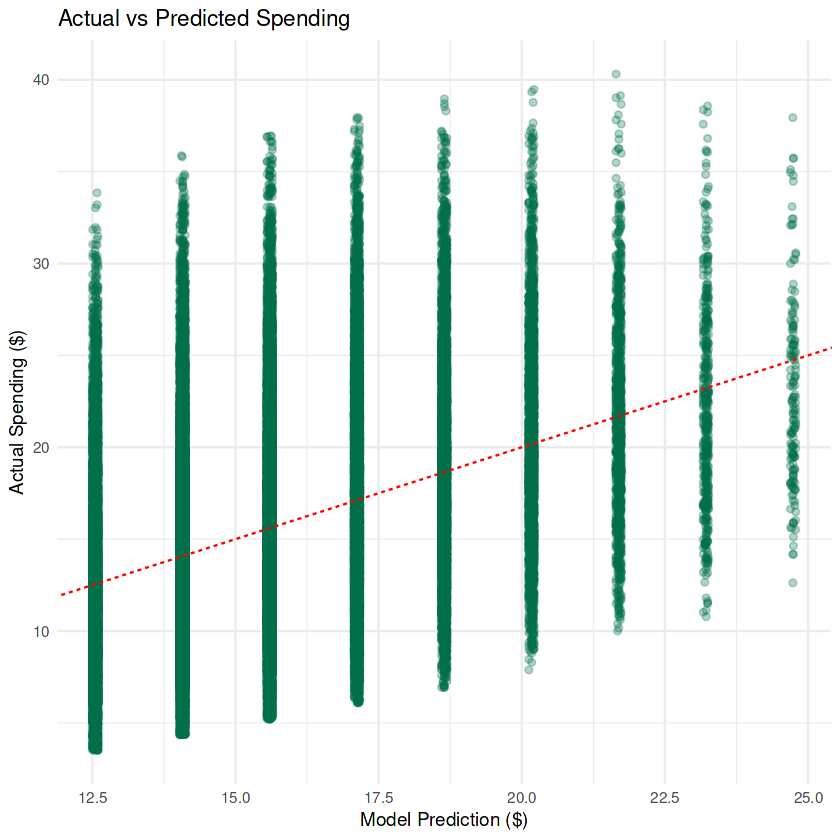

In [16]:
#visualization
reg_data$predicted_spend <- predict(revenue_model)
ggplot(reg_data, aes(x = predicted_spend, y = total_spend)) +
  geom_point(alpha = 0.3, color = "#00704A") +
  geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed") +
  theme_minimal() +
  labs(title = "Actual vs Predicted Spending",
       x = "Model Prediction ($)",
       y = "Actual Spending ($)")


This analysis aims to pinpoint operational inefficiencies during the peak morning rush (06:00 AM - 10:00 AM) by comparing Drive-Thru and Mobile App fulfillment times.
> * Process: I filtered the dataset for morning peak hours and focused on the two primary channels. A Boxplot was used to visualize the distribution of fulfillment times and identify potential outliers—orders that took an unusually long time to complete.

> * Insight: A higher median or more outliers in the Mobile App channel might suggest a "digital bottleneck," where baristas struggle to balance digital tickets with in-person customers. Conversely, slow Drive-Thru times indicate physical capacity constraints. Identifying these gaps allows Starbucks to optimize labor allocation during peak hours.

In [17]:
#Analyze fulfillment_time_min to find operational inefficiencies between Drive-Thru and Mobile Order-Ahead during peak morning rushes.
# 1. Filter data for morning rush hour (6:00 a.m. to 10:00 a.m.)
# And compare Drive-Thru vs. Mobile Order-Ahead
morning_rush <- starbuck_customer_data %>%
  mutate(hour = as.numeric(substr(order_time, 1, 2))) %>%
  filter(hour >= 6 & hour <= 10) %>%
  filter(order_channel %in% c("Drive-Thru", "Mobile App"))

In [18]:
# 2. Calculate Bottleneck Statistics
bottleneck_analysis <- morning_rush %>%
  group_by(order_channel) %>%
  summarise(
    avg_wait_time = mean(fulfillment_time_min, na.rm = TRUE),
    max_wait_time = max(fulfillment_time_min, na.rm = TRUE),
    total_orders = n()
  )

print(bottleneck_analysis)

# A tibble: 2 × 4
  order_channel avg_wait_time max_wait_time total_orders
  <chr>                 <dbl>         <dbl>        <int>
1 Drive-Thru             5.80          11.2        10531
2 Mobile App             4.49           8.9        15934


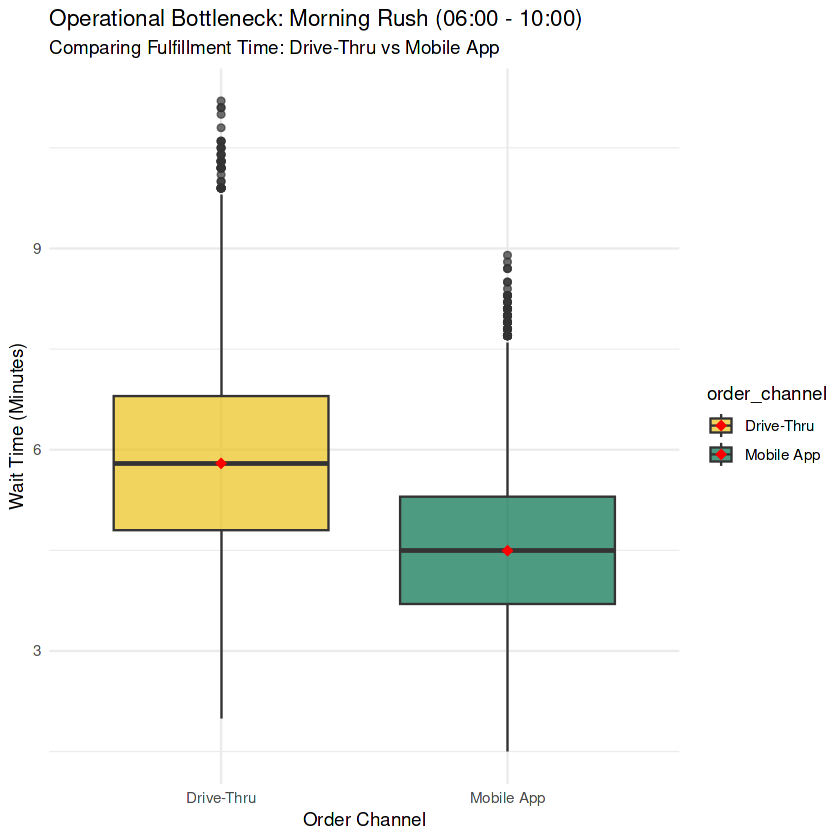

In [19]:
# 3. Visualization for Bottleneck Identification
ggplot(morning_rush, aes(x = order_channel, y = fulfillment_time_min, fill = order_channel)) +
  geom_boxplot(alpha = 0.7) +
  stat_summary(fun = mean, geom = "point", shape = 18, size = 3, color = "red") +
  scale_fill_manual(values = c("Drive-Thru" = "#EAC117", "Mobile App" = "#00704A")) +
  theme_minimal() +
  labs(
    title = "Operational Bottleneck: Morning Rush (06:00 - 10:00)",
    subtitle = "Comparing Fulfillment Time: Drive-Thru vs Mobile App",
    x = "Order Channel",
    y = "Wait Time (Minutes)"
  )

Loyalty Program Impact Study: Evaluate how "Rewards Member" status
> correlates with basket size, visit frequency, and overall customer satisfaction.

In [20]:
#Member vs non-Member performance
loyalty_impact <- starbuck_customer_data %>% 
  group_by(is_rewards_member) %>% 
  summarise(
    avg_basket_size = mean(cart_size, na.rm = TRUE),
    avg_frequency = n() / n_distinct(customer_id),
    avg_spend = mean(total_spend, na.rm = TRUE),
    total_customers = n_distinct(customer_id)
  )
print(loyalty_impact)

# A tibble: 2 × 5
  is_rewards_member avg_basket_size avg_frequency avg_spend total_customers
  <lgl>                       <dbl>         <dbl>     <dbl>           <int>
1 FALSE                        3.71          2.75      14.7           13804
2 TRUE                         3.95          2.90      16.3           13782


In [21]:
#T Test to make sure the loyalty program make big difference to our customers
t_test_basket <- t.test(cart_size ~ is_rewards_member, data = starbuck_customer_data)
print(t_test_basket)

t_test_spend <- t.test(total_spend ~ is_rewards_member, data = starbuck_customer_data)
print(t_test_spend)


	Welch Two Sample t-test

data:  cart_size by is_rewards_member
t = -19.536, df = 77904, p-value < 2.2e-16
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -0.2648747 -0.2165732
sample estimates:
mean in group FALSE  mean in group TRUE 
           3.713069            3.953793 




	Welch Two Sample t-test

data:  total_spend by is_rewards_member
t = -41.125, df = 77934, p-value < 2.2e-16
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -1.725943 -1.568912
sample estimates:
mean in group FALSE  mean in group TRUE 
           14.69039            16.33781 



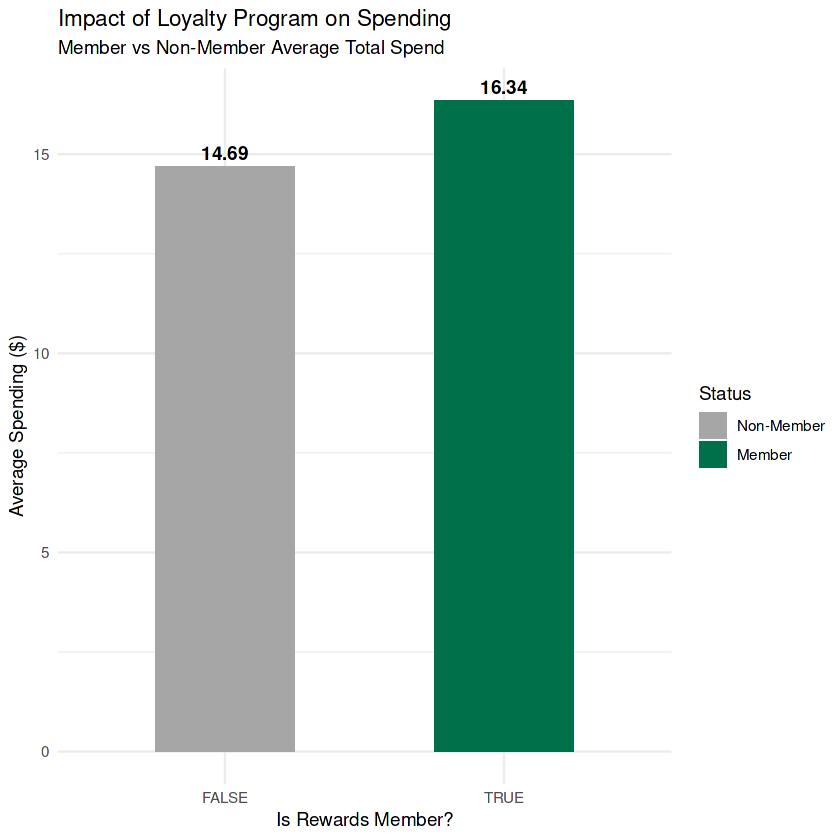

In [22]:
#visualization loyalty impact
ggplot(loyalty_impact, aes(x = is_rewards_member, y = avg_spend, fill = as.factor(is_rewards_member))) +
  geom_col(width = 0.5) +
  scale_fill_manual(values = c("TRUE" = "#00704A", "FALSE" = "#A6A6A6"), 
                    labels = c("Non-Member", "Member")) + # Memberikan label rapi di legenda
  theme_minimal() +
  labs(
    title = "Impact of Loyalty Program on Spending",
    subtitle = "Member vs Non-Member Average Total Spend",
    x = "Is Rewards Member?",
    y = "Average Spending ($)",
    fill = "Status"
  ) +
  geom_text(aes(label = round(avg_spend, 2)), vjust = -0.5, fontface = "bold")

In [23]:
# Counting amount of customization per drink category
menu_analysis <-  starbuck_customer_data %>% 
  group_by(drink_category) %>% 
  summarise(
    avg_customization = mean(num_customizations, na.rm = TRUE),
    total_orders = n(),
    avg_spend = mean(total_spend, na.rm = TRUE)
  ) %>% 
  arrange(desc(avg_customization))
print(menu_analysis)

# A tibble: 6 × 4
  drink_category avg_customization total_orders avg_spend
  <chr>                      <dbl>        <int>     <dbl>
1 Other                       1.96        12907      15.5
2 Tea                         1.96        13017      15.6
3 Espresso                    1.95        13075      15.5
4 Refresher                   1.95        13120      15.5
5 Brewed Coffee               1.95        12869      15.5
6 Frappuccino                 1.94        12949      15.6


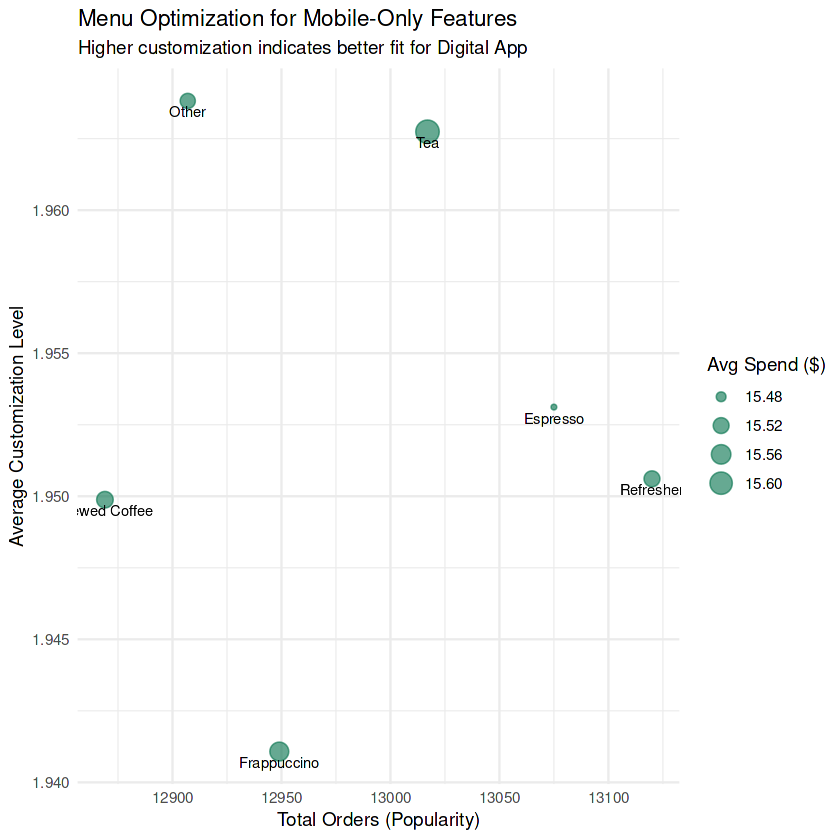

In [24]:
#visualization
ggplot(menu_analysis, aes(x = total_orders, y = avg_customization, size = avg_spend, label = drink_category)) +
  geom_point(alpha = 0.6, color = "#00704A") +
  geom_text(vjust = 1.5, size = 3, check_overlap = TRUE) +
  theme_minimal() +
  labs(
    title = "Menu Optimization for Mobile-Only Features",
    subtitle = "Higher customization indicates better fit for Digital App",
    x = "Total Orders (Popularity)",
    y = "Average Customization Level",
    size = "Avg Spend ($)"
  )
